In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import pandas as pd

# 엑셀 파일 경로
tourism_path = '/content/drive/MyDrive/Colab Notebooks/tour/tourist_spots_with_addresses.csv'

df_tourism = pd.read_csv(tourism_path)

df_tourism.head(2)

,addr1,addr2,areacode,booktour,cat1,cat2,cat3,contentid,contenttypeid,createdtime,...,firstimage2,cpyrhtDivCd,mapx,mapy,mlevel,modifiedtime,sigungucode,tel,title,zipcode
0,충청남도 공주시 감영길 3,(반죽동),34.0,NaN,쇼핑,쇼핑,전문매장/상가,2750144,38,20210928012320,...,NaN,NaN,127.121672,36.452930,6.0,20241226163730,1.0,NaN,가가상점,32546
1,부산광역시 부산진구 중앙번영로 (6),NaN,6.0,NaN,음식,음식점,일식,2805408,39,20220125140006,...,NaN,NaN,129.059828,35.144807,6.0,20240104133528,7.0,NaN,가가와,47361


In [3]:
transport_path = '/content/drive/MyDrive/Colab Notebooks/tour/관광지_대중교통_매칭최종.xlsx'

df_transport = pd.read_excel(transport_path, engine='openpyxl')

df_transport.head(2)

,title,addr1,addr2,areacode,booktour,cat1,cat2,cat3,contentid,contenttypeid,...,mapy,mlevel,modifiedtime,sigungucode,tel,zipcode,closest_subway_station,closest_subway_line,closest_bus_station,closest_bus_id
0,"(고성) 숨은 영화 촬영지가 궁금할 때, 고성 무비 로드",강원특별자치도 고성군 죽왕면 왕곡마을길 35,NaN,32.0,NaN,추천코스,가족코스,가족코스,2514959,25,...,38.340226,6.0,20230809091829,2.0,NaN,24746,NaN,NaN,NaN,NaN
1,(구)인천일본제58은행지점,인천광역시 중구 신포로23번길 69-1 중구음식업지부,NaN,2.0,0.0,인문(문화/예술/역사),역사관광지,유적지/사적지,945221,12,...,37.472867,6.0,20240603104004,10.0,NaN,22314,인천역,"['경인선', '수인선']",중구청입구,ICB161000894


In [4]:
df = pd.merge(df_tourism, df_transport, on=['title', 'addr1'], how='inner')

In [5]:
df.head(2)

,addr1,addr2_x,areacode_x,booktour_x,cat1_x,cat2_x,cat3_x,contentid_x,contenttypeid_x,createdtime_x,...,mapy_y,mlevel_y,modifiedtime_y,sigungucode_y,tel_y,zipcode_y,closest_subway_station,closest_subway_line,closest_bus_station,closest_bus_id
0,충청남도 공주시 감영길 3,(반죽동),34.0,NaN,쇼핑,쇼핑,전문매장/상가,2750144,38,20210928012320,...,36.452930,6.0,20241226163730,1.0,NaN,32546,NaN,NaN,사대부고,SJB286034019
1,부산광역시 부산진구 중앙번영로 (6),NaN,6.0,NaN,음식,음식점,일식,2805408,39,20220125140006,...,35.144807,6.0,20240104133528,7.0,NaN,47361,범내골역,['부산 도시철도 1호선'],중앙시장,BSB510100000


In [6]:
def clean_suffix_columns(df: pd.DataFrame, suffixes=("_x", "_y", "_a", "_b")):
    import re
    from collections import defaultdict

    # 접미사 제거한 기준 이름으로 그룹화
    col_groups = defaultdict(list)
    for col in df.columns:
        match = re.match(r"^(.*)(_x|_y|_a|_b)$", col)
        if match:
            base = match.group(1)
            col_groups[base].append(col)

    # 유지할 컬럼과 이름 변경
    keep_rename = {}
    drop_cols = []

    for base, cols in col_groups.items():
        # 우선순위: _x > _y > _a > _b > 기타
        priority = sorted(cols, key=lambda c: suffixes.index(c[-2:]) if c[-2:] in suffixes else len(suffixes))
        keep = priority[0]
        keep_rename[keep] = base
        drop_cols.extend([c for c in cols if c != keep])

    # 컬럼 이름 변경 및 삭제
    df = df.rename(columns=keep_rename)
    df = df.drop(columns=drop_cols, errors="ignore")

    return df

df = clean_suffix_columns(df)

In [7]:
# 접근성 점수
df['access_score'] = df['closest_subway_station'].notna().astype(int) + df['closest_bus_station'].notna().astype(int)

In [8]:
df.head(2)

,addr1,addr2,areacode,booktour,cat1,cat2,cat3,contentid,contenttypeid,createdtime,...,modifiedtime,sigungucode,tel,title,zipcode,closest_subway_station,closest_subway_line,closest_bus_station,closest_bus_id,access_score
0,충청남도 공주시 감영길 3,(반죽동),34.0,NaN,쇼핑,쇼핑,전문매장/상가,2750144,38,20210928012320,...,20241226163730,1.0,NaN,가가상점,32546,NaN,NaN,사대부고,SJB286034019,1
1,부산광역시 부산진구 중앙번영로 (6),NaN,6.0,NaN,음식,음식점,일식,2805408,39,20220125140006,...,20240104133528,7.0,NaN,가가와,47361,범내골역,['부산 도시철도 1호선'],중앙시장,BSB510100000,2


In [9]:
# 2. 카테고리 점수 (단순 개수 기준)
cat1_freq = df['cat1'].value_counts()
df['cat1_score'] = df['cat1'].map(lambda x: cat1_freq.get(x, 0))
df['cat1_score'] = 10 * (df['cat1_score'] - df['cat1_score'].min()) / (df['cat1_score'].max() - df['cat1_score'].min())


In [10]:
# 3. 날짜 점수: 최근일수록 높게
df['modifiedtime'] = pd.to_datetime(df['modifiedtime'], errors='coerce', format='%Y%m%d%H%M%S')
df['modified_score'] = 10 * (df['modifiedtime'] - df['modifiedtime'].min()) / (df['modifiedtime'].max() - df['modifiedtime'].min())


In [11]:
# 4. 밀집도 점수
from sklearn.neighbors import NearestNeighbors
coords = df[['mapy', 'mapx']].dropna().values
nn = NearestNeighbors(n_neighbors=6).fit(coords)
distances, _ = nn.kneighbors(coords)
density_score = 1 / (distances[:, 1:].mean(axis=1) + 1e-6)
df.loc[df[['mapy', 'mapx']].dropna().index, 'density_score'] = 10 * (density_score - density_score.min()) / (density_score.max() - density_score.min())


In [12]:
# =========[ 1) Imports & 설정 ]=========
from pathlib import Path
import json, time, os, hashlib
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.base import clone
import joblib

# 전처리(항상 이 셀에서 임포트)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
import scipy.sparse as sp  # TF-IDF 캐시 저장용 (선택)

In [13]:
# =========[ 2) 데이터(df) 준비 ]=========
# df: 아래 컬럼이 있어야 함 -> title, access_score, cat1_score, modified_score, density_score
assert 'df' in globals(), "df를 먼저 로드하세요."
Y_COLS = ['access_score', 'cat1_score', 'modified_score', 'density_score']
X_COL  = 'title'
need_cols = [X_COL] + Y_COLS

df_train = df.dropna(subset=need_cols).copy()
X_text = df_train[X_COL].astype(str).to_numpy()
Y_all  = df_train[Y_COLS].to_numpy()  # (n,4)

In [14]:
# =========[ 3) Colab 절대경로 체크포인트 고정 ]=========
DRIVE_BASE = Path("/content/drive/MyDrive/Colab Notebooks/tour")
CKPT_DIR   = (DRIVE_BASE / "_ckpt" / "model_cv").resolve()
CKPT_DIR.mkdir(parents=True, exist_ok=True)

R2_CKPT_PATH    = CKPT_DIR / "r2_ckpt.json"       # 시드별 CV 결과/진행상태
BEST_MODEL_JSON = CKPT_DIR / "best_model.json"    # 최고 모델명/스코어
BEST_MODEL_PATH = CKPT_DIR / "best_model.joblib"  # 최종 학습 모델
PRED_PATH       = CKPT_DIR / "pred_df.parquet"
SORTED_PATH     = CKPT_DIR / "df_sorted.parquet"
SORTED_CSV_PATH = CKPT_DIR / "df_sorted.csv"

# 피처 캐시
FEAT_DIR   = CKPT_DIR / "feat_cache"
FEAT_DIR.mkdir(parents=True, exist_ok=True)
X_SVD_PATH = FEAT_DIR / "X_svd.npy"
TFIDF_PATH = FEAT_DIR / "tfidf_csr.npz"          # 선택 저장
META_PATH  = FEAT_DIR / "feat_meta.json"

print(f"[CKPT DIR] {CKPT_DIR}")

[CKPT DIR] /content/drive/MyDrive/Colab Notebooks/tour/_ckpt/model_cv


In [15]:
# =========[ 4) JSON 로드/저장 ]=========
def load_json(path, default):
    if path.exists():
        try:
            return json.loads(path.read_text(encoding="utf-8"))
        except Exception:
            pass
    return default

def save_json(path, obj):
    tmp = path.with_suffix(path.suffix + ".tmp")
    tmp.write_text(json.dumps(obj, ensure_ascii=False, indent=2), encoding="utf-8")
    tmp.replace(path)

In [16]:
# =========[ 5) TF-IDF + SVD '한 번만' 계산/캐시 ]=========
TFIDF_CFG = dict(analyzer="char", ngram_range=(2,4), min_df=1, max_features=20000, dtype=np.float32)
SVD_NCOMP = 64

def corpus_digest(texts, k=1000):
    sample = texts if len(texts) <= k else texts[:k]
    m = hashlib.md5()
    for t in sample: m.update(t.encode("utf-8", "ignore"))
    return f"{len(texts)}_{m.hexdigest()}"

# JSON 직렬화 가능한 형태로 변환
def to_jsonable_cfg(cfg: dict) -> dict:
    d = dict(cfg)
    if "dtype" in d:
        d["dtype"] = "float32"  # 문자열로 저장
    for k, v in list(d.items()):
        if isinstance(v, tuple): d[k] = list(v)
    return d

cfg_serializable = to_jsonable_cfg(TFIDF_CFG)
meta_need = {"tfidf": cfg_serializable, "svd_ncomp": int(SVD_NCOMP), "corpus": corpus_digest(X_text)}
meta_have = load_json(META_PATH, {})

recompute = (meta_have != meta_need) or (not X_SVD_PATH.exists())

if recompute:
    print("[FEAT] Computing TF-IDF on full corpus...")
    tfidf = TfidfVectorizer(**TFIDF_CFG)
    X_tfidf = tfidf.fit_transform(X_text)  # (N, V) sparse

    # 선택: TF-IDF도 저장(원치 않으면 주석)
    try:
        sp.save_npz(str(TFIDF_PATH), X_tfidf)
    except Exception as e:
        print(f"[WARN] TF-IDF save skipped: {e}")

    print("[FEAT] SVD fitting...")
    svd = TruncatedSVD(n_components=SVD_NCOMP, random_state=0)
    X_feat = svd.fit_transform(X_tfidf).astype(np.float32)  # (N, d)

    np.save(X_SVD_PATH, X_feat)
    save_json(META_PATH, meta_need)
    print(f"[FEAT] Saved: {X_SVD_PATH.name} shape={X_feat.shape}")
else:
    print("[FEAT] Loading cached features...")
    X_feat = np.load(X_SVD_PATH, mmap_mode="r")
    print(f"[FEAT] Loaded: {X_SVD_PATH.name} shape={X_feat.shape}")

[FEAT] Loading cached features...
[FEAT] Loaded: X_svd.npy shape=(50159, 64)


In [17]:
# =========[ 6) 모델/시드 스위치 ==========
# EVAL_MODELS = ["Ridge", "HGBR",]  # 두개 평가
EVAL_MODELS = ["Ridge", "HGBR", "GBDT"]  # 모두 평가
N_SEEDS     = 20
seeds       = list(range(N_SEEDS))

In [18]:
# =========[ 7) 베이스 모델 정의 (전처리 끝난 X_feat 사용) ]=========
ridge_est = Ridge(alpha=2.0)

hgbr_single = HistGradientBoostingRegressor(
    max_iter=300, learning_rate=0.05,
    early_stopping=True, n_iter_no_change=10,
    random_state=0
)
hgbr_est = MultiOutputRegressor(hgbr_single, n_jobs=-1)  # 4타깃 병렬

gbdt_single = GradientBoostingRegressor(
    n_estimators=300, learning_rate=0.05,
    max_depth=3, subsample=0.9,
    random_state=0,
    n_iter_no_change=10, validation_fraction=0.1
)
gbdt_est = MultiOutputRegressor(gbdt_single, n_jobs=-1)

base_models = {"Ridge": ridge_est, "HGBR": hgbr_est, "GBDT": gbdt_est}
base_models = {k: v for k, v in base_models.items() if k in EVAL_MODELS}

In [19]:
# =========[ 8) 반복 홀드아웃 + 체크포인트 재개 (빠른 재개) ]=========
ckpt = load_json(R2_CKPT_PATH, {"seeds": seeds, "results": {}})
ckpt["seeds"] = seeds
save_json(R2_CKPT_PATH, ckpt)

avg_scores = {}
for name, est in base_models.items():
    print(f"\n[START] {name}")
    ckpt = load_json(R2_CKPT_PATH, {"seeds": seeds, "results": {}})
    res = ckpt["results"].get(name, {"done": [], "r2_list": []})
    done_set = set(int(x) for x in res.get("done", []))
    missing = [s for s in seeds if s not in done_set]
    print(f"[RESUME] {name}: done={sorted(done_set)} missing={missing}")

    for seed in missing:
        X_tr, X_te, Y_tr, Y_te = train_test_split(X_feat, Y_all, test_size=0.2, random_state=seed)

        model = clone(est)
        t0 = time.time()
        model.fit(X_tr, Y_tr)
        Y_pred = model.predict(X_te)

        r2_targets = [r2_score(Y_te[:, i], Y_pred[:, i]) for i in range(Y_te.shape[1])]
        mean_r2 = float(np.mean(r2_targets))

        res.setdefault("done", []).append(int(seed))
        res.setdefault("r2_list", []).append({"seed": int(seed), "mean": mean_r2})
        ckpt["results"][name] = res
        save_json(R2_CKPT_PATH, ckpt)

        print(f"[{name}] seed={seed:02d}  r2_mean={mean_r2:.4f}  (+{time.time()-t0:.1f}s)")

    res["avg"] = float(np.mean([it["mean"] for it in res.get("r2_list", [])])) if res.get("r2_list") else float("nan")
    ckpt["results"][name] = res
    save_json(R2_CKPT_PATH, ckpt)
    avg_scores[name] = res["avg"]
    print(f"[DONE]  {name}")

print("\n모델별 평균 R²(타깃 평균):")
for k, v in sorted(avg_scores.items(), key=lambda x: -x[1]):
    print(f"  {k:5s}: {v:.4f}")

best_model_name = max(avg_scores, key=avg_scores.get)
print(f"\n✅ 최종 선택된 모델: {best_model_name}")
save_json(BEST_MODEL_JSON, {"best_model": best_model_name, "avg_scores": avg_scores})


[START] Ridge
[RESUME] Ridge: done=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19] missing=[]
[DONE]  Ridge

[START] HGBR
[RESUME] HGBR: done=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19] missing=[]
[DONE]  HGBR

[START] GBDT
[RESUME] GBDT: done=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19] missing=[]
[DONE]  GBDT

모델별 평균 R²(타깃 평균):
  HGBR : 0.6526
  GBDT : 0.5450
  Ridge: 0.3855

✅ 최종 선택된 모델: HGBR


In [20]:
# =========[ 9) 전체 학습 (best_model로 전체 데이터 적합) ]=========
need_train = True
if BEST_MODEL_PATH.exists() and BEST_MODEL_JSON.exists():
    meta = load_json(BEST_MODEL_JSON, {})
    if meta.get("best_model") == best_model_name:
        try:
            best_model = joblib.load(BEST_MODEL_PATH)
            need_train = False
            print(f"📦 로드: {BEST_MODEL_PATH.name} (model={best_model_name})")
        except Exception:
            need_train = True

if need_train:
    print("🧠 전체 데이터로 최종 모델 학습 중...")
    best_model = clone(base_models[best_model_name])
    best_model.fit(X_feat, Y_all)
    joblib.dump(best_model, BEST_MODEL_PATH)
    print(f"💾 저장: {BEST_MODEL_PATH}")

📦 로드: best_model.joblib (model=HGBR)


In [21]:
# =========[ 10) 예측/점수 산출 ]=========
def save_parquet(df_obj, path):
    try:
        df_obj.to_parquet(path, index=True)
        return True
    except Exception:
        df_obj.to_csv(path.with_suffix('.csv'), index=True, encoding='utf-8-sig')
        return False

def load_parquet(path):
    try:
        return pd.read_parquet(path)
    except Exception:
        alt = path.with_suffix('.csv')
        if alt.exists():
            return pd.read_csv(alt, index_col=0)
        raise

if PRED_PATH.exists() or PRED_PATH.with_suffix('.csv').exists():
    pred_df = load_parquet(PRED_PATH)
    if len(pred_df) != len(df_train):
        print("⚠️ pred_df 크기 불일치 → 재계산")
        Y_hat = best_model.predict(X_feat)
        pred_df = pd.DataFrame(Y_hat, columns=[f'pred_{c}' for c in Y_COLS], index=df_train.index)
        save_parquet(pred_df, PRED_PATH)
else:
    Y_hat = best_model.predict(X_feat)  # (n,4)
    pred_df = pd.DataFrame(Y_hat, columns=[f'pred_{c}' for c in Y_COLS], index=df_train.index)
    save_parquet(pred_df, PRED_PATH)
    print(f"💾 저장: {PRED_PATH.name} (또는 CSV 폴백)")

In [22]:
# =========[ 11) model_score / tour_score 계산 + 저장 ]=========
pred_access_10   = np.clip(pred_df['pred_access_score'].to_numpy(), 0.0, 2.0) * 5.0
pred_cat1_10     = np.clip(pred_df['pred_cat1_score'].to_numpy(),     0.0, 10.0)
pred_modified_10 = np.clip(pred_df['pred_modified_score'].to_numpy(), 0.0, 10.0)
pred_density_10  = np.clip(pred_df['pred_density_score'].to_numpy(),  0.0, 10.0)

df.loc[df_train.index, 'model_score'] = (
    pred_access_10 + pred_cat1_10 + pred_modified_10 + pred_density_10
) / 4.0

df.loc[df_train.index, 'tour_score'] = (
    df.loc[df_train.index, 'access_score'] +
    df.loc[df_train.index, 'cat1_score'] +
    df.loc[df_train.index, 'density_score'] +
    df.loc[df_train.index, 'modified_score'] +
    df.loc[df_train.index, 'model_score']
) / 5.0

out_cols = ['title','addr1','tour_score','model_score'] + Y_COLS
df_sorted = df.loc[df_train.index, out_cols].sort_values('tour_score', ascending=False).reset_index(drop=True)

df_sorted.head(5)

,title,addr1,tour_score,model_score,access_score,cat1_score,modified_score,density_score
0,모담 현대백화점킨텍스점,경기도 고양시 일산서구 호수로 817 (대화동),8.023848,8.813933,2,10.0,9.305306,10.0
1,장독대김치찜김치찌개_용산점,서울특별시 용산구 한강대로23길 55 (한강로3가),7.807697,7.176666,2,10.0,9.861820,10.0
2,경성한우불고기 송도컨벤시아 본점,인천광역시 연수구 센트럴로 123 송도컨벤시아,7.798967,7.387984,2,10.0,9.606852,10.0
3,식물학 아이파크몰점,서울특별시 용산구 한강대로23길 55 (한강로3가),7.782992,7.053141,2,10.0,9.861820,10.0
4,고든램지버거,서울특별시 송파구 올림픽로 300 롯데월드타워앤드롯데월드몰,7.782867,7.473453,2,10.0,9.440883,10.0


In [23]:
# 저장 (Parquet + CSV)
try:
    df_sorted.to_parquet(SORTED_PATH, index=False)
    print(f"💾 저장: {SORTED_PATH}")
except Exception as e:
    print(f"[WARN] Parquet 저장 실패({e}) → CSV로 저장")
df_sorted.to_csv(SORTED_CSV_PATH, index=False, encoding='utf-8-sig', float_format="%.4f")
print(f"💾 저장: {SORTED_CSV_PATH}")

💾 저장: /content/drive/MyDrive/Colab Notebooks/tour/_ckpt/model_cv/df_sorted.parquet
💾 저장: /content/drive/MyDrive/Colab Notebooks/tour/_ckpt/model_cv/df_sorted.csv


In [46]:
# === 0) Colab 한글 폰트 세팅 ===
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

# 폰트 설치(Barun 포함) + 캐시 초기화
!apt-get update -qq
!apt-get install -y fonts-nanum fonts-nanum-extra fonts-noto-cjk >/dev/null

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm
import shutil, os, sys

# 캐시 삭제 & 재로딩
shutil.rmtree(mpl.get_cachedir(), ignore_errors=True)
fm._load_fontmanager(try_read_cache=False)

# 우선순위: NanumBarunGothic > NanumGothic > Noto Sans CJK KR
candidates = ["NanumBarunGothic", "NanumGothic", "Noto Sans CJK KR"]
avail = {n: any(n in f.name for f in fm.fontManager.ttflist) for n in candidates}
chosen = next((n for n in candidates if avail.get(n)), "DejaVu Sans")

plt.rcParams["font.family"] = [chosen]
plt.rcParams["axes.unicode_minus"] = False
print("Using font:", chosen)


import json, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path

def plot_r2_beeswarm_portfolio_kr(
    ckpt_path,
    baseline="Ridge",
    spacing=0.50,       # 모델 군 간 간격(작을수록 촘촘)
    jitter=0.12,        # 군 내부 흩뿌림 폭
    s=22,               # 점 크기
    font_scale=1.15,    # 전체 폰트 스케일 (축/제목/틱/라벨 전부)
    ann_dx_px=26,       # 주석 라벨의 좌우 픽셀 오프셋(겹침 방지)
    ann_dy_px=10,       # 주석 라벨의 위쪽 픽셀 오프셋
    ann_box=True,
    save=None, dpi=300, figsize=(8.2, 5.6)
):
    # ---- 데이터 로드 ----
    ckpt = json.loads(Path(ckpt_path).read_text(encoding="utf-8"))
    rows=[]
    for m, res in ckpt.get("results", {}).items():
        for it in res.get("r2_list", []):
            rows.append({"model": m, "seed": it["seed"], "r2": float(it["mean"])})
    df_r2 = pd.DataFrame(rows)
    if df_r2.empty: raise ValueError("시드별 R² 데이터가 없습니다.")

    stats = df_r2.groupby("model")["r2"].agg(["mean","std"]).sort_values("mean", ascending=False)
    order = stats.index.tolist()
    x = np.arange(len(order), dtype=float) * spacing

    # ---- 폰트 스케일 적용 ----
    base = plt.rcParams.get("font.size", 10.0)
    rc = {
        "font.size": base * font_scale,
        "axes.titlesize": base * 1.4 * font_scale,
        "axes.labelsize": base * 1.2 * font_scale,
        "xtick.labelsize": base * 1.0 * font_scale,
        "ytick.labelsize": base * 1.0 * font_scale,
        "legend.fontsize": base * 1.0 * font_scale,
    }

    with plt.rc_context(rc):
        fig = plt.figure(figsize=figsize, dpi=dpi)
        ax = plt.gca()

        # ---- 점(비스웜) ----
        rng = np.random.default_rng(0)
        jitter_width = min(jitter, spacing * 0.35)
        for i, m in enumerate(order):
            arr = df_r2.loc[df_r2["model"]==m, "r2"].to_numpy()
            j = (rng.random(len(arr)) - 0.5) * 2 * jitter_width
            ax.scatter(np.full_like(arr, x[i]) + j, arr, s=s, alpha=0.85)

        # ---- 평균±표준편차 ----
        mean = stats["mean"].to_numpy()
        std  = stats["std"].to_numpy()
        ax.errorbar(x, mean, yerr=std, fmt="s", ms=7, capsize=4, linewidth=1.2)

        # ---- 주석: 좌우 번갈아 픽셀 오프셋으로 겹침 방지 ----
        # 예: 3개면 [-dx, 0, +dx]로 배치
        if len(order) == 1:
            offsets = [0]
        elif len(order) == 2:
            offsets = [-ann_dx_px, +ann_dx_px]
        else:
            offsets = np.linspace(-ann_dx_px, ann_dx_px, len(order))

        if baseline in stats.index:
            base_mean = stats.loc[baseline, "mean"]
        else:
            base_mean = None

        for i, m in enumerate(order):
            text = f"{mean[i]:.3f}"
            if base_mean is not None:
                d = mean[i] - base_mean
                text += f"\nRidge 대비: {d:+.3f}"

            ax.annotate(
                text,
                xy=(x[i], mean[i] + (std[i] if not np.isnan(std[i]) else 0)),
                xycoords="data",
                xytext=(offsets[i], ann_dy_px),     # 👈 픽셀 기준 좌우/위 오프셋
                textcoords="offset points",
                ha="center", va="bottom",
                fontsize=base * 1.0 * font_scale,
                bbox=(dict(boxstyle="round,pad=0.25", fc="white", ec="0.7", alpha=0.95) if ann_box else None),
                arrowprops=dict(arrowstyle="-", lw=0.8, alpha=0.85),
                clip_on=False, annotation_clip=False
            )

        # ---- 축/레이아웃 ----
        pad = spacing * 0.7
        ax.set_xlim(x.min() - pad, x.max() + pad)
        ax.set_xticks(x, order)
        ax.set_ylim(0, 1)
        ax.set_ylabel("R² (시드별, 4개 타깃 평균)")
        ax.set_title("모델 리더보드 – R² 분포(비스웜) + 평균±표준편차")
        ax.grid(axis="y", linestyle="--", alpha=0.35)
        plt.tight_layout()
        if save: plt.savefig(save, bbox_inches="tight", dpi=dpi)
        plt.show()



W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


Using font: NanumBarunGothic


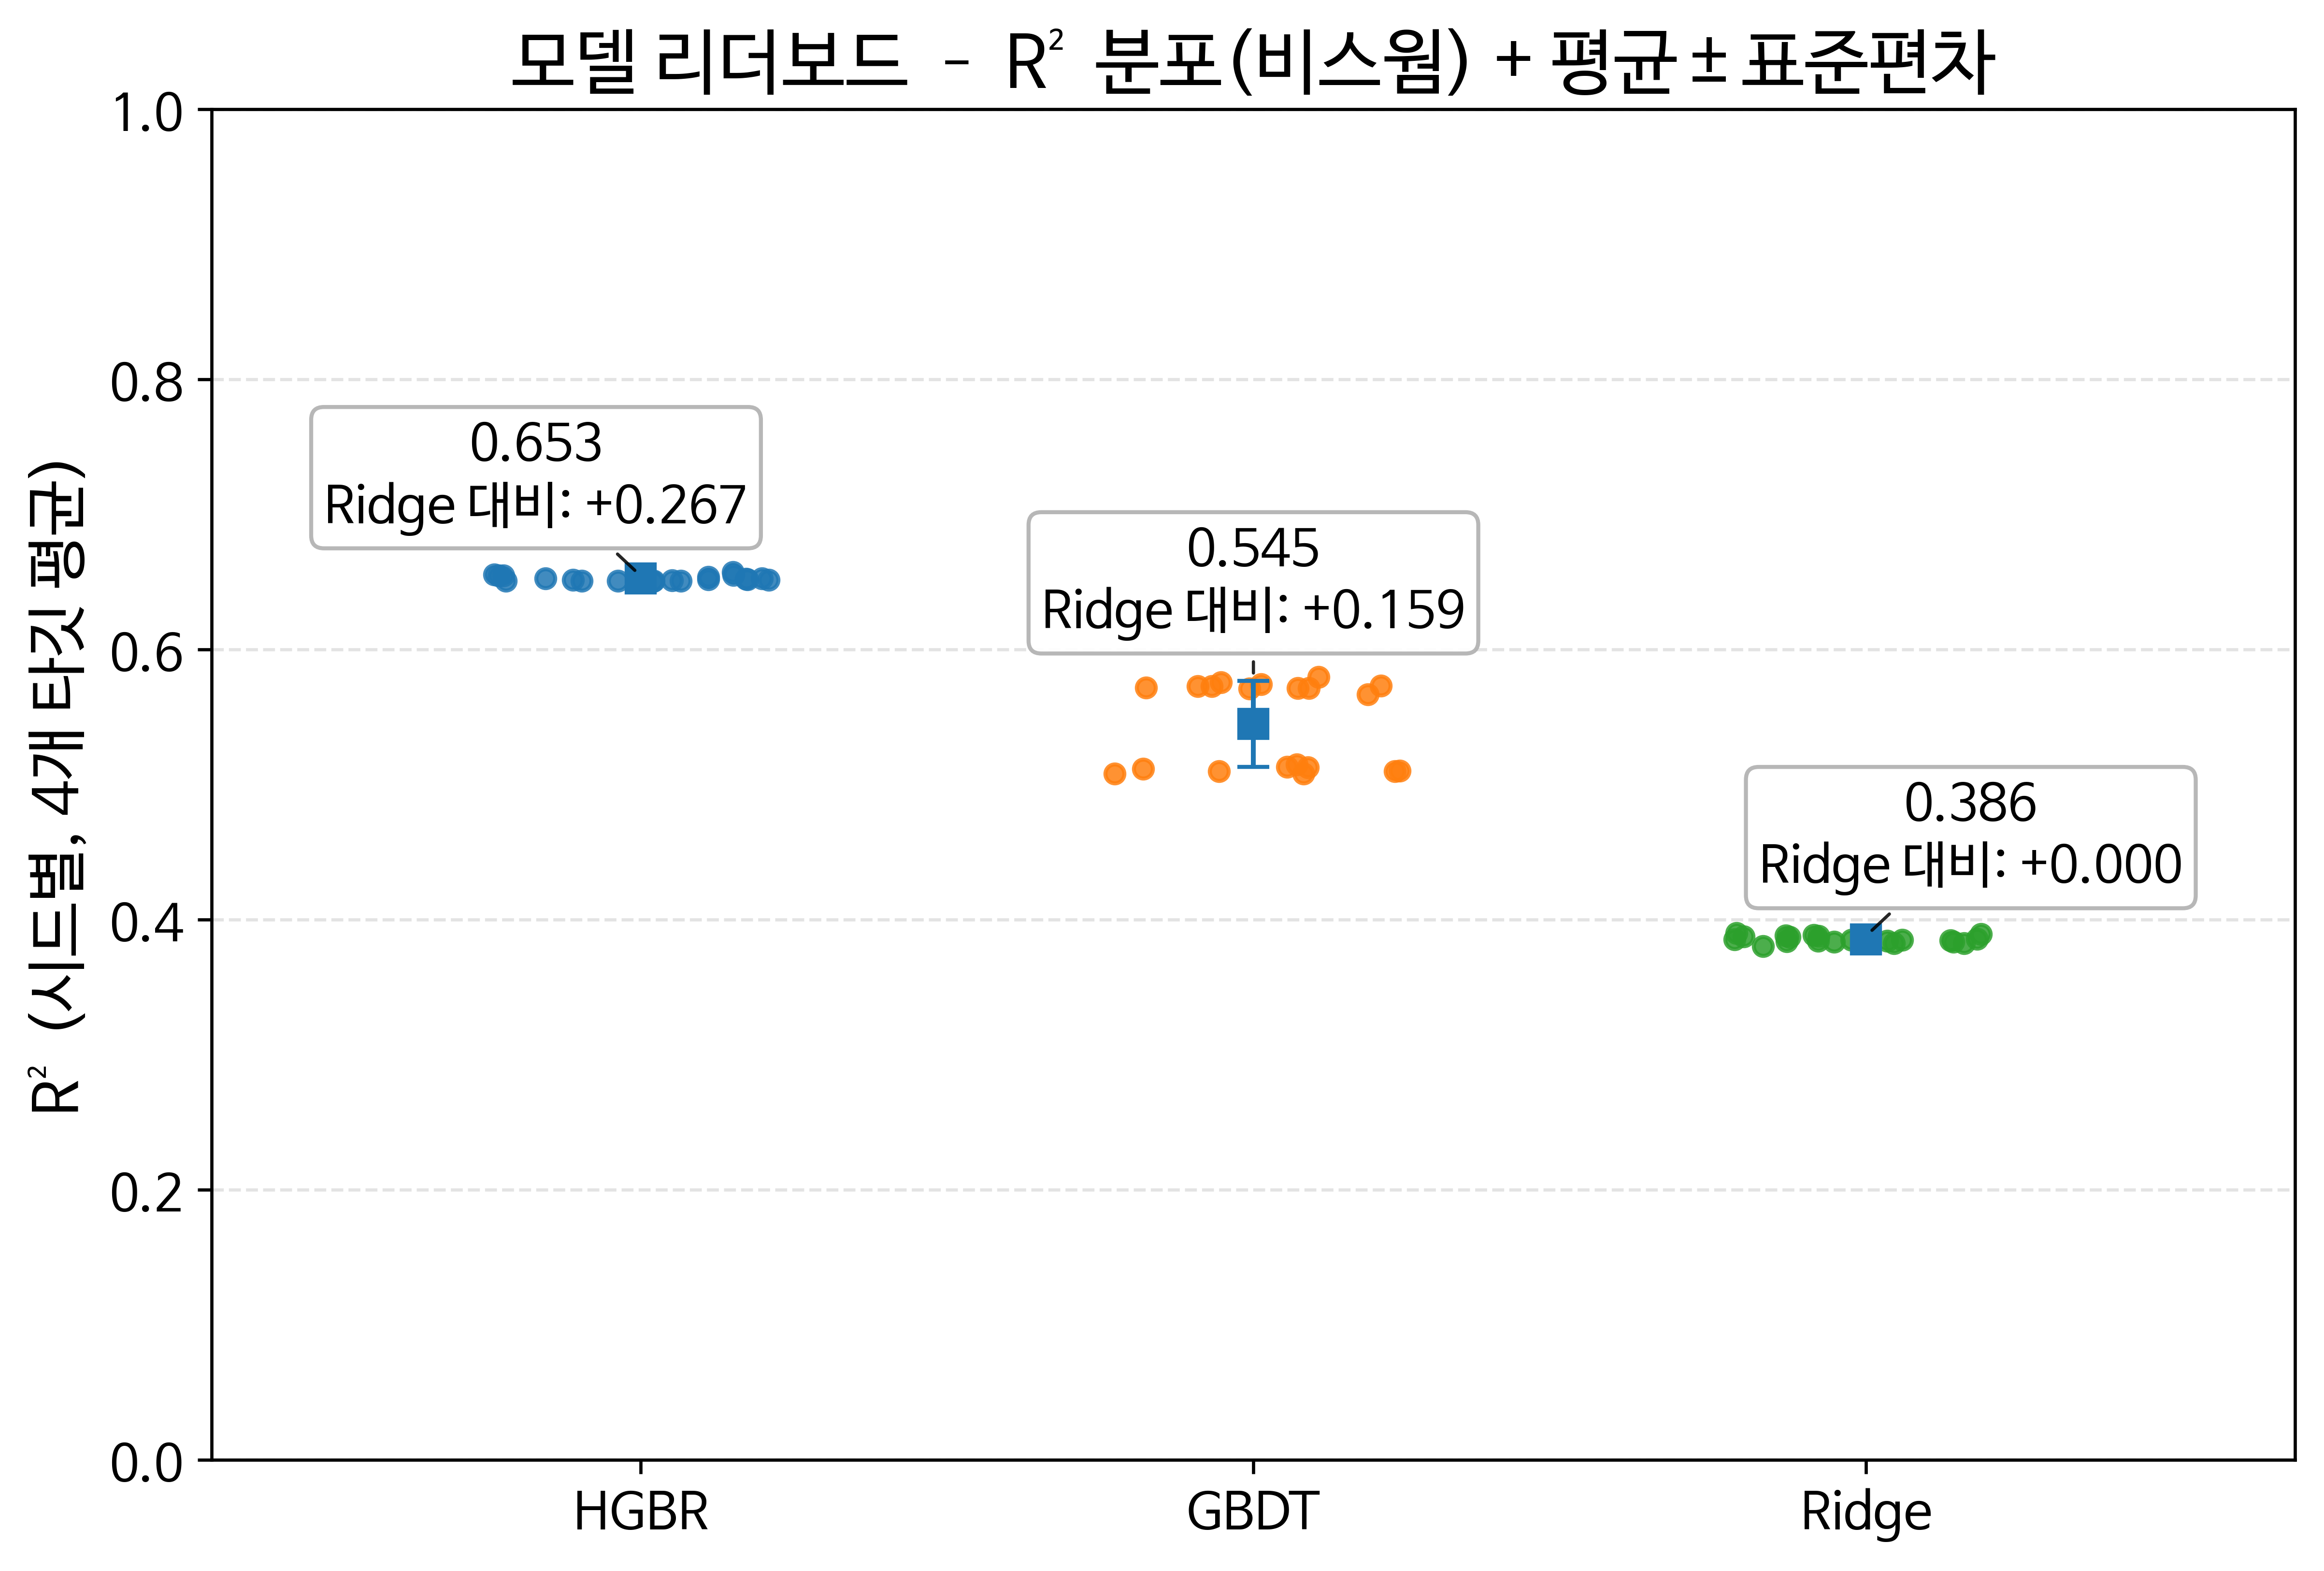

In [47]:

plot_r2_beeswarm_portfolio_kr(R2_CKPT_PATH, baseline="Ridge")